In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

In [2]:
# =========================
# Parameters
# =========================

Nn = 100
L = 25.0
m = 1.0
beta = 1
lam = 1/np.sqrt(Nn)
U0 = 1
Ul = U0 * lam
g = 4
wDrive = -1
k = 2 * np.pi / L
Ulk = Ul * k

G = 10.0
Gmk = G* m*k

dt = 5e-3
tmax = 2000
nSteps = int(np.ceil(tmax / dt))
Psi0 = 1
nuc = 1/(Psi0*beta*L**2)
xL=np.linspace(0,L,1000)

In [3]:
# =========================
# Core functions
# =========================
def dU(x):
    return -U0*lam*k*np.sin(k*x)
def dPsi(x,phi):
    return -Psi0*g*lam*k*np.sin(k*x+phi)
def nu(x,w, phi):
    A=2*beta*np.cosh(beta*w/2)*(np.cosh(beta*w)+2)
    B = np.exp(-beta*w/2)*(np.exp(2*beta*w)+np.exp(beta*w)-2)
    return (A*(dU(x))**2+B*dU(x)*dPsi(x,phi))/(9*Psi0*(2*np.cosh(beta*w)+1)**2)

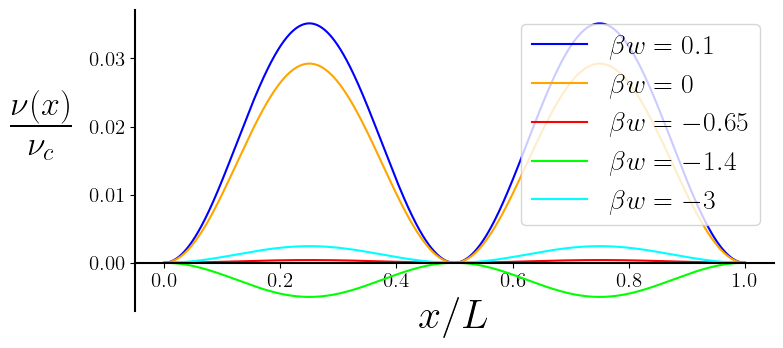

In [7]:
# =========================
# \nu(x) for different \beta w
# =========================
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(xL/L, nu(xL,0.1,0)/nuc, label = r"$\beta w = 0.1$", color = 'blue')
plt.plot(xL/L, nu(xL,0,0)/nuc, label = r"$\beta w = 0$", color = 'orange')
plt.plot(xL/L, nu(xL,-0.65,0)/nuc, label = r"$\beta w = -0.65$", color = 'red')
plt.plot(xL/L, nu(xL,-1.4,0)/nuc, label = r"$\beta w = -1.4$", color = 'lime')
plt.plot(xL/L, nu(xL,-3.5,0)/nuc, label = r"$\beta w = -3$", color = 'cyan')

ax.set_ylabel(r"$\frac{\nu(x)}{\nu_c}$", fontsize = 35, rotation = 0,labelpad=35)
ax.set_xlabel(r"$x/L$", fontsize = 30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 20, loc = 'upper right')
plt.tight_layout()
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
# Move x-axis to y = 0
ax.spines['bottom'].set_position(('data', 0))

# Ensure ticks are on the moved axis
ax.xaxis.set_ticks_position('bottom')
#plt.savefig('nuwf2.png',bbox_inches='tight') #activate when you want to save the figure
plt.show()


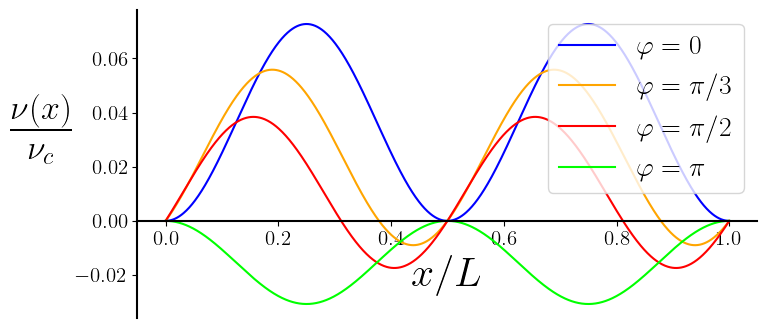

In [6]:
# =========================
# \nu(x) for different \varphi
# =========================
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(xL/L, nu(xL,1,0)/nuc, label = r"$\varphi = 0$", color = 'blue')
plt.plot(xL/L, nu(xL,1,np.pi/3)/nuc, label = r"$\varphi = \pi/3$", color = 'orange')
plt.plot(xL/L, nu(xL,1,np.pi/2)/nuc, label = r"$\varphi = \pi/2$", color = 'red')
plt.plot(xL/L, nu(xL,1,np.pi)/nuc, label = r"$\varphi = \pi$", color = 'lime')
ax.set_ylabel(r"$\frac{\nu(x)}{\nu_c}$", fontsize = 35, rotation = 0,labelpad=25)
ax.set_xlabel(r"$x/L$", fontsize = 30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 20, loc = 'upper right')
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
# Move x-axis to y = 0
ax.spines['bottom'].set_position(('data', 0))

# Ensure ticks are on the moved axis
ax.xaxis.set_ticks_position('bottom')
#plt.savefig('nuphif2.png',bbox_inches='tight')  #activate when you want to save the figure
plt.show()